# Coupling GeoEnthalpyDelta component with Landscape evolution for alluvial fans


In [1]:
import numpy as np

from landlab import RasterModelGrid, imshow_grid
from landlab.components import FlowAccumulator,LinearDiffuser, StreamPowerEroder

In this example we create a large grid with 2 distinct domain for upstream and downstream

Start by defining some parameters:

In [2]:
K = 4.0e-4
D = 0.02
nrows, ncols = 100, 100
dx = 100.0 # grid spacing in meters
slope_gradient__upstream = -0.5
slope_gradient__downstream = -0.02
slope_break = ncols * dx / 2 # 1/2 of the domain
noise_amplitude = 10 # amplitude for random noise
input_runoff = 500000.0 # drainage equivalent

uplift_rate_1 = 1e-4
uplift_rate_2 = 1e-1
dt = dx / (K * (dx * dx * input_runoff) ** 0.5)
run_duration = 25.0 / uplift_rate_2
num_steps = int(run_duration / dt)


Create grid and topography and set boundaries

In [3]:
grid = RasterModelGrid((nrows, ncols), xy_spacing=dx)
# set the rightest edge to be open  
grid.set_closed_boundaries_at_grid_edges(False, True, True, True)
#create synthetic elevation field as a ramp with break in 2 different domains
base = grid.add_zeros("basement__elevation", at="node")
x = grid.x_of_node.reshape(grid.shape)
x_flat = x.reshape(-1)
base[:] = np.where(
    x_flat <= slope_break,
    slope_gradient__upstream * x_flat,
    slope_gradient__upstream * slope_break + slope_gradient__downstream * (x_flat - slope_break),
)
np.random.seed(0)
base[grid.core_nodes] += noise_amplitude * np.random.randn(grid.number_of_core_nodes)
grid.at_node["topographic__elevation"] = grid.at_node["basement__elevation"].copy()
topo = grid.at_node["topographic__elevation"]

Preview the synthetic elevation

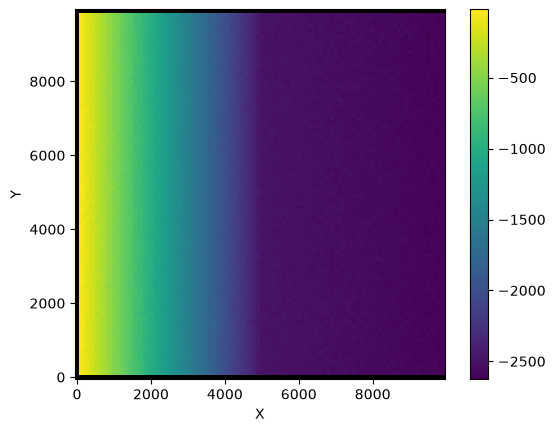

In [4]:
from landlab.plot import imshow_grid
imshow_grid(grid, "topographic__elevation", cmap="viridis")

## Setting up `FlowAccumulator`

This component will help us to identify drainage direction (taken the example from Landscape Evolution tutorial, we will follow D8 method), and also find the drainage area and surface water discharge

In [5]:
# FlowAccumulator component
fa = FlowAccumulator(grid, flow_director="FlowDirectorD8")
sp = StreamPowerEroder(grid, K_sp=K, discharge_field="surface_water__discharge")
ld = LinearDiffuser(grid, linear_diffusivity=D)

In [6]:
runoff = grid.add_ones("water__unit_flux_in", at="node", clobber=True)
left_middle_node = 4950
runoff[left_middle_node] = input_runoff

In [14]:
core_nodes = grid.core_nodes
core_x = x_flat[core_nodes]
upstream_core = core_nodes[core_x <= slope_break]
downstream_core = core_nodes[core_x > slope_break]

for _ in range(num_steps*10):
    uplift_rates = np.interp(core_x[core_x <= slope_break], [core_x[core_x <= slope_break].min(), slope_break], [uplift_rate_2, uplift_rate_1])
    topo[upstream_core] = topo[upstream_core] + uplift_rates * dt
    topo[downstream_core] = topo[downstream_core] + uplift_rate_1 * dt

    fa.run_one_step()
    ld.run_one_step(dt)
    sp.run_one_step(dt)

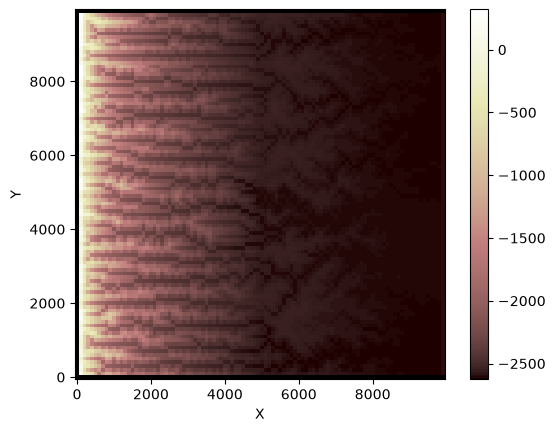

In [40]:
imshow_grid(grid, topo)

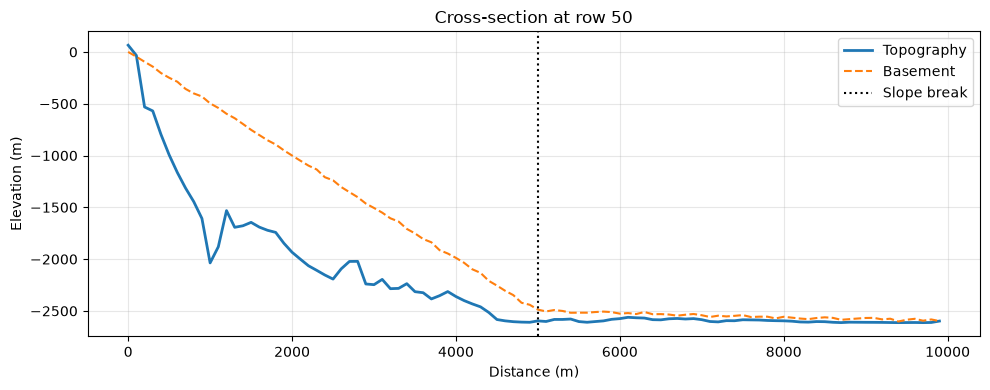

In [38]:
import matplotlib.pyplot as plt

# Convert node fields to 2D raster layers
grid_layers = grid.node_vector_to_raster(topo)
base_layers = grid.node_vector_to_raster(base)

# Cross-section along the middle row
row_idx = nrows // 2
x_section = x[row_idx, :]
topo_section = grid_layers[row_idx, :]
base_section = base_layers[row_idx, :]

plt.figure(figsize=(10, 4))
plt.plot(x_section, topo_section, label="Topography", lw=2)
plt.plot(x_section, base_section, label="Basement", lw=1.5, ls="--")
plt.axvline(slope_break, color="k", ls=":", label="Slope break")
plt.xlabel("Distance (m)")
plt.ylabel("Elevation (m)")
plt.title(f"Cross-section at row {row_idx}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
from landlab.components import GeoEnthalpyDelta

# Update basement elevation to current topography
grid.at_node["basement__elevation"] = grid.at_node["topographic__elevation"].copy()

# Initialize GeoEnthalpyDelta component
esd = GeoEnthalpyDelta(
    grid,
    sediment_flux=1000,
    feeder_width=2000,
    sea_level_start=-1000,
    sea_level_rise_rate=0.0,
    topset_threshold_x=0.3,
    topset_threshold_y=0.2,
    foreset_threshold_x=2.0,
    foreset_threshold_y=2.0,
    topset_diffusivity_x=1.0,
    topset_diffusivity_y=1.0,
    foreset_diffusivity_x=1.0,
    foreset_diffusivity_y=1.0,
)
dt_esd = esd.calc_stable_time_step()
# Run GeoEnthalpyDelta
esd.run_one_step(dt)

In [34]:
dt

3.535533905932737

In [35]:
for _ in range(10000):
    esd.run_one_step(dt)

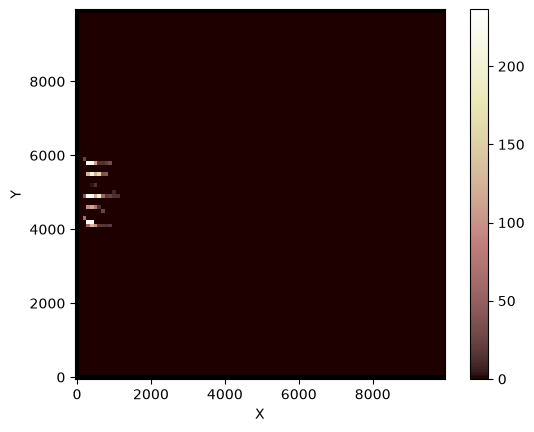

In [36]:
imshow_grid(grid, "sediment__thickness")